In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E415050160>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E415027B20>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [2]:

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
# model = ChatGroq(model="openai/gpt-oss-120b")
model = ChatGroq(model="llama-3.3-70b-versatile")
model

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E469A226E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E4152948B0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [4]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative', 'neutral'] = Field(..., description="The sentiment of the essay")

In [5]:
structed_model = model.with_structured_output(SentimentSchema)

In [8]:
prompt = "What is the sentiment of the following essay? 'I love programming. It is so much fun and I enjoy solving problems.'"

structed_model.invoke(prompt)

SentimentSchema(sentiment='positive')

In [10]:
class ReviewState(TypedDict):
    
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: str
    response: str

In [12]:
def find_sentiment(state: ReviewState):
    prompt = f"What is the sentiment of the following review? '{state['review']}'"
    result = structed_model.invoke(prompt)
    return {'sentiment': result.sentiment}

def check_sentiment(state: ReviewState) ->  Literal["positive_response", "run_diagnosis"]:
    
    if state["sentiment"] == "positive":
        return "positive_response"
    
    else: 
        return "run_diagnosis"
    

In [15]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)

graph.add_edge(START, "find_sentiment")
graph.add_edge("find_sentiment", END)

workflow = graph.compile()


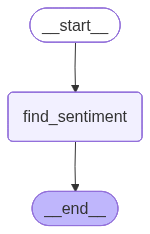

In [16]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### addiing conditional edges

In [17]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm", "happy"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high", "neutral"] = Field(description='How urgent or critical the issue appears to be')

In [18]:
structured_model2 = model.with_structured_output(DiagnosisSchema)
structured_model2

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E469A226E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E4152948B0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'DiagnosisSchema', 'description': '', 'parameters': {'properties': {'issue_type': {'description': 'The category of issue mentioned in the review', 'enum': ['UX', 'Performance', 'Bug', 'Support', 'Other'], 'type': 'string'}, 'tone': {'description': 'The emotional tone expressed by the user', 'enum': ['angry', 'frustrated', 'disappointed', 'calm', 'happy'], 'type': 'string'}, 'urge

In [19]:
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = llm.invoke(prompt).content

    return {'response': response}


def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)
    
    print(response) ## json type output with tone, urgency and issue_type

    return {'diagnosis': response.model_dump()} ## convert json to dictionary type


def negative_response(state: ReviewState):
    
    diagnosis = state["diagnosis"]

    prompt = f"""Based on this review and diagnosis, draft a compassionate response addressing the user's concerns:
    \n\nReview: \"{state['review']}\"\n
    Diagnosis: {state['diagnosis']}\n
    Tone: {diagnosis['tone']}\n
    Urgency: {diagnosis['urgency']}\n   
    Issue Type: {diagnosis['issue_type']}\n
    Ensure to apologize for any inconvenience and offer assistance to resolve the issue."""
    
    response = llm.invoke(prompt).content

    return {'response': response}
    

In [21]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, "find_sentiment")

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge("positive_response", END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge("negative_response", END)

workflow = graph.compile()


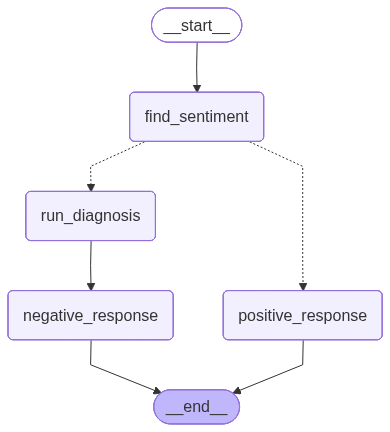

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [23]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}

workflow.invoke(intial_state)

issue_type='Bug' tone='angry' urgency='high'


{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': 'Hi\u202f[User],\n\nI’m really sorry you’re stuck on the authentication screen and that reinstalling didn’t help. I completely understand how frustrating it is to be unable to log in, especially when you need the app right away.\n\n**What we can do right now**\n\n1. **Clear any leftover data** – Even after a reinstall, cached files can remain. Please try the following:  \n   - On Android: Settings\u202f→\u202fApps\u202f→\u202f[Your App]\u202f→\u202fStorage\u202f→\u202fClear Cache & Clear Data.  \n   - On iOS: Settings\u202f→\u202fGeneral\u202f→\u202fiPhone Storage\u202f→\u202f[Your App]\u202f→\u202fDelete App, then restart your device 

In [ ]:
# intial_state={
#     'review': "Thank you for the product. We are very satisfied with the quality and overall performance. It meets our requirements well, and the delivery was smooth. We appreciate the support and look forward to working with you again."
# }

# workflow.invoke(intial_state)

{'review': 'Thank you for the product. We are very satisfied with the quality and overall performance. It meets our requirements well, and the delivery was smooth. We appreciate the support and look forward to working with you again.',
 'sentiment': 'positive',
 'response': 'Dear [Customer Name],\n\nThank you so much for sharing your wonderful review! We’re thrilled to hear that you’re satisfied with the quality and performance of our product, and that the delivery process met your expectations. Knowing that we’ve been able to support your needs means a lot to us, and we truly appreciate your kind words.\n\nWe look forward to the opportunity to work with you again and continue providing the service you deserve. When you have a moment, we’d be grateful if you could share your experience as a feedback post on our website – it helps us improve and assists other customers in making informed decisions.\n\nThank you once again for your trust and partnership.\n\nWarm regards,  \n[Your Name]  

In [24]:
review = """Thank you for the product. We are very satisfied with the quality and overall performance. 
It meets our requirements well, and the delivery was smooth. We appreciate the support and look forward to working with you again."""


workflow.invoke({'review': review})


{'review': 'Thank you for the product. We are very satisfied with the quality and overall performance. \nIt meets our requirements well, and the delivery was smooth. We appreciate the support and look forward to working with you again.',
 'sentiment': 'positive',
 'response': 'Dear\u202f[Customer Name],\n\nThank you so much for sharing your wonderful review! We’re thrilled to hear that the product meets your requirements, that you’re satisfied with its quality and performance, and that the delivery process was smooth. Your kind words about our support mean a great deal to the whole team.\n\nWe truly appreciate the trust you’ve placed in us and look forward to continuing our partnership on future projects. If you have a moment, we’d be grateful if you could share your experience as feedback on our website – it helps us improve and assists other customers in making informed decisions.\n\nThank you again for your support. Please don’t hesitate to reach out whenever you need anything.\n\nW